In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

In [7]:
url = "https://archive.ics.uci.edu/static/public/12/data.csv"
df=pd.read_csv(url,header=0)
print(df.head())  
print(len(df))
print(df.shape)
#Torque=weight×distance
#If left torque > right torque → L
#If right torque > left torque → R
#If equal → B

  class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5
625
(625, 5)


In [9]:
##Check for null or NAN values
#for col in df.columns:
   # null_count=df[col].isna().sum()
    #print(f" {col} has {null_count} null values" )

null_df = pd.DataFrame({
    'column_name': df.columns,
    'null_count': df.isna().sum().values
})

print(null_df)

      column_name  null_count
0           class           0
1     left-weight           0
2   left-distance           0
3    right-weight           0
4  right-distance           0


## Split Data Train Test

In [32]:
X = df.iloc[:, 1:5].values #except the first column
Y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

# Train using Gini

In [33]:
model_gini=DecisionTreeClassifier(criterion='gini',max_depth=3,min_samples_leaf=5,random_state=100)
model_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Train using Entropy

In [34]:
model_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=3,min_samples_leaf=5,random_state=100)
model_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred_gini=model_gini.predict(X_test)
y_pred_entropy=model_entropy.predict(X_test)

In [36]:
def calculate_accuracy(y_test,y_pred):
    print("\n Confusion Matrix \n", confusion_matrix(y_test,y_pred))
    print("\n Accuracy Score \n", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [37]:
#Accuracy for model_gini
calculate_accuracy(y_test,y_pred_gini)


 Confusion Matrix 
 [[ 0  6  7]
 [ 0 67 18]
 [ 0 19 71]]

 Accuracy Score 
 73.40425531914893

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        13
           L       0.73      0.79      0.76        85
           R       0.74      0.79      0.76        90

    accuracy                           0.73       188
   macro avg       0.49      0.53      0.51       188
weighted avg       0.68      0.73      0.71       188



C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
#Accuracy for model_entropy
calculate_accuracy(y_test,y_pred_entropy)


 Confusion Matrix 
 [[ 0  6  7]
 [ 0 63 22]
 [ 0 20 70]]

 Accuracy Score 
 70.74468085106383

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        13
           L       0.71      0.74      0.72        85
           R       0.71      0.78      0.74        90

    accuracy                           0.71       188
   macro avg       0.47      0.51      0.49       188
weighted avg       0.66      0.71      0.68       188



C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ashutosh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [39]:
def plot_decision_tree (model_name,feature_names,class_names):
    plt.figure(figsize=(15,10))
    plot_tree(model_name,filled=True,feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

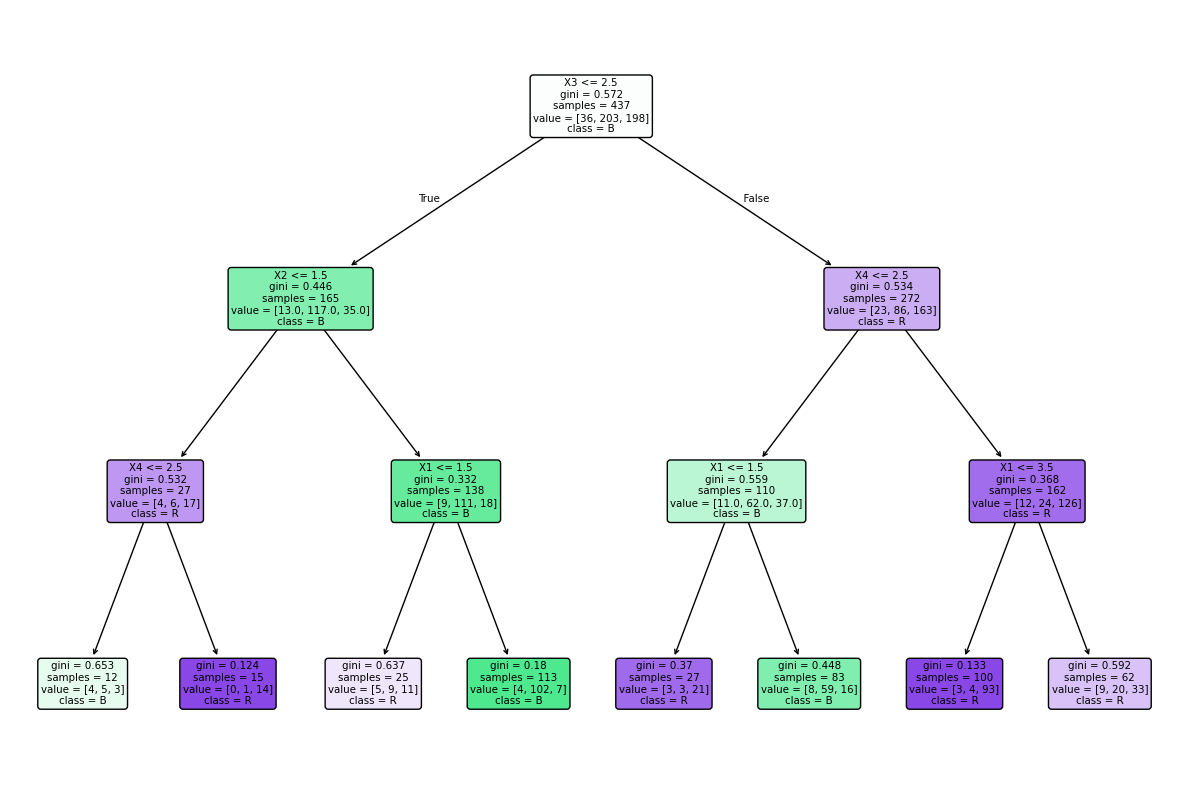

In [40]:
##plot for model_gini
plot_decision_tree(model_gini,['X1', 'X2', 'X3', 'X4'],['L', 'B', 'R'])

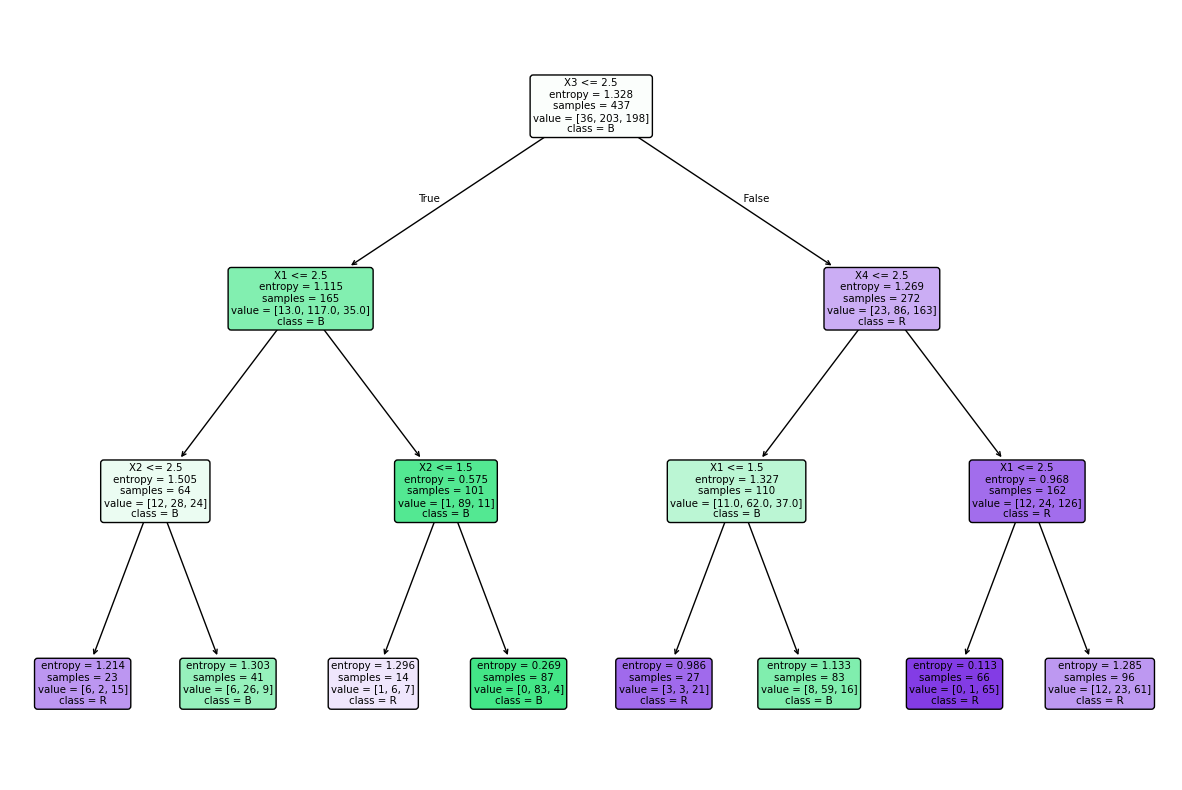

In [41]:
##plot for model_gini
plot_decision_tree(model_entropy,['X1', 'X2', 'X3', 'X4'],['L', 'B', 'R'])